# Конструкция алгоритма генерации квадратных графов

Функция генерации графа в виде прямоугольной сетки с шагом.

In [1]:
import osmnx as ox
from osmnx import utils
import networkx as nx
import numpy as np
import pandas as pd

In [ ]:
def generate_grid_graph(n: int, 
                        m: int, 
                        step: float = 100.0,
                        speed: float = 50.0,
                        crs = 'EPSG:3857',
                        add_geometry: bool = True) -> nx.MultiDiGraph:
    '''
    Генерация графа улично-дорожной сети в виде прямоугольной сетки.
    
    Аргументы:
        `n`: int
            Количество узлов по оси X (ширина сетки)
        
        `m`: int
            Количество узлов по оси Y (высота сетки)
        
        `step`: float = 100.0
            Расстояние между соседними узлами (в метрах)
        
        `speed`: float или tuple = 50.0
            Скорость движения по ребрам (км/ч) для расчета времени в пути.
            Может быть:
            - float: единственное значение скорости для всех ребер
            - tuple: ((speed1, speed2, ...), (prob1, prob2, ...))
              где первый кортеж содержит скорости, второй - вероятности их выбора.
              Сумма вероятностей должна быть строго равна 1.0
              Пример: ((30, 40, 50), (0.2, 0.5, 0.3))

        `crs`: str = 'EPSG:3857
            Система координат
        
        `add_geometry`: bool = True
            Добавлять ли геометрию (LineString) к ребрам
    
    Возвращает:
        `G`: nx.MultiDiGraph
            Направленный мультиграф с узлами и ребрами в виде сетки
    '''
    from shapely.geometry import Point, LineString
    
    # Валидация параметра speed
    if isinstance(speed, tuple):
        if len(speed) != 2:
            raise ValueError("Параметр speed в формате tuple должен содержать 2 элемента: ((speeds...), (probs...))")
        
        speeds, probs = speed
        
        if len(speeds) != len(probs):
            raise ValueError(f"Количество скоростей ({len(speeds)}) должно совпадать с количеством вероятностей ({len(probs)})")
        
        if not isinstance(speeds, (tuple, list)) or not isinstance(probs, (tuple, list)):
            raise ValueError("Скорости и вероятности должны быть tuple или list")
        
        # Проверка суммы вероятностей
        prob_sum = sum(probs)
        if not np.isclose(prob_sum, 1.0, atol=1e-6):
            raise ValueError(f"Сумма вероятностей должна быть равна 1.0, текущая сумма: {prob_sum}")
        
        # Проверка, что все вероятности неотрицательны
        if any(p < 0 for p in probs):
            raise ValueError("Все вероятности должны быть неотрицательными")
        
        # Проверка, что все скорости положительны
        if any(s <= 0 for s in speeds):
            raise ValueError("Все значения скорости должны быть положительными")
    
    # Создание пустого мультиграфа
    metadata = {
            "created_date": utils.ts(),
            "created_with": f"OSMnx {ox.__version__}",
            "crs": crs
        }
    G = nx.MultiDiGraph(**metadata)

    
    # Генерация узлов
    node_id = 0
    node_positions = {}  # Для хранения соответствия (i, j) -> node_id
    
    for i in range(n):
        for j in range(m):
            # Координаты узла
            x = i * step
            y = j * step
            
            # Добавление узла с атрибутами
            G.add_node(node_id, 
                      x=x, 
                      y=y,
                      # pos=(x, y),
                      geometry=Point(x, y) if add_geometry else None)
            
            node_positions[(i, j)] = node_id
            node_id += 1
    
    # Генерация ребер между соседними узлами
    for i in range(n):
        for j in range(m):
            current_node = node_positions[(i, j)]
            
            # Соединяем с правым соседом (i+1, j)
            if i + 1 < n:
                right_node = node_positions[(i + 1, j)]
                add_edge_with_attributes(G, current_node, right_node, step, speed, add_geometry)
                add_edge_with_attributes(G, right_node, current_node, step, speed, add_geometry)
            
            # Соединяем с верхним соседом (i, j+1)
            if j + 1 < m:
                top_node = node_positions[(i, j + 1)]
                add_edge_with_attributes(G, current_node, top_node, step, speed, add_geometry)
                add_edge_with_attributes(G, top_node, current_node, step, speed, add_geometry)
    
    return G


def add_edge_with_attributes(G, u, v, length, speed, add_geometry=True):
    '''
    Добавляет ребро с необходимыми атрибутами.
    
    Аргументы:
        `G`: nx.MultiDiGraph
            Граф
        `u`, `v`: int
            Узлы начала и конца ребра
        `length`: float
            Длина ребра (в метрах)
        `speed`: float или tuple
            Скорость движения (км/ч). Может быть:
            - float: единственное значение скорости
            - tuple: ((speed1, speed2, ...), (prob1, prob2, ...))
        `add_geometry`: bool
            Добавлять ли геометрию LineString
    '''
    from shapely.geometry import LineString
    
    # Определение скорости для данного ребра
    if isinstance(speed, tuple):
        # Формат: ((speeds...), (probs...))
        speeds, probs = speed
        actual_speed = np.random.choice(speeds, p=probs)
    else:
        # Единственное значение скорости
        actual_speed = speed
    
    # Расчет времени в пути (в секундах)
    # length в метрах, actual_speed в км/ч
    # travel_time = (length / 1000.0) / actual_speed * 3600.0  # секунды
    travel_time = length / (actual_speed * 1000 / 60)        # минуты
    
    # Атрибуты ребра
    edge_attrs = {
        'length': length,
        'travel_time': travel_time,
        'speed_kph': actual_speed,
    }
    
    # Добавление геометрии если требуется
    if add_geometry:
        u_data = G.nodes[u]
        v_data = G.nodes[v]
        edge_attrs['geometry'] = LineString([
            (u_data['x'], u_data['y']),
            (v_data['x'], v_data['y'])
        ])
    
    G.add_edge(u, v, **edge_attrs)


def remove_random_elements(G, 
                          remove_nodes: int = 0, 
                          remove_edges: int = 0,
                          copy: bool = True) -> nx.MultiDiGraph:
    '''
    Случайное удаление узлов или ребер из графа.
    
    Аргументы:
        `G`: nx.MultiDiGraph
            Исходный граф
        
        `remove_nodes`: int = 0
            Количество узлов для удаления
        
        `remove_edges`: int = 0
            Количество ребер для удаления
        
        `copy`: bool = True
            Создавать копию графа (True) или изменять исходный (False)
    
    Возвращает:
        `G_modified`: nx.MultiDiGraph
            Граф с удаленными элементами
    '''
    import random
    
    if copy:
        G = G.copy()
    
    # Удаление случайных узлов
    if remove_nodes > 0:
        nodes_list = list(G.nodes())
        nodes_to_remove = random.sample(nodes_list, min(remove_nodes, len(nodes_list)))
        G.remove_nodes_from(nodes_to_remove)
    
    # Удаление случайных ребер
    if remove_edges > 0:
        edges_list = list(G.edges(keys=True))
        edges_to_remove = random.sample(edges_list, min(remove_edges, len(edges_list)))
        for u, v, k in edges_to_remove:
            G.remove_edge(u, v, k)
    
    return G

In [3]:
# Пример: удаление случайных элементов
G_original = generate_grid_graph(n=10, m=10, step=100.0)
print(f"Исходный граф: {G_original.number_of_nodes()} узлов, {G_original.number_of_edges()} ребер")

# Удаление 20 узлов
G_nodes = remove_random_elements(G_original, remove_nodes=20)
print(f"После удаления 20 узлов: {G_nodes.number_of_nodes()} узлов, {G_nodes.number_of_edges()} ребер")

# Удаление 50 ребер
G_edges = remove_random_elements(G_original, remove_edges=50)
print(f"После удаления 50 ребер: {G_edges.number_of_nodes()} узлов, {G_edges.number_of_edges()} ребер")

# Удаление и узлов, и ребер
G_both = remove_random_elements(G_original, remove_nodes=10, remove_edges=30)
print(f"После удаления 10 узлов и 30 ребер: {G_both.number_of_nodes()} узлов, {G_both.number_of_edges()} ребер")


Исходный граф: 100 узлов, 360 ребер
После удаления 20 узлов: 80 узлов, 240 ребер
После удаления 50 ребер: 100 узлов, 310 ребер
После удаления 10 узлов и 30 ребер: 90 узлов, 260 ребер


## Пример 1: Простая сетка 5×5

In [4]:
# Генерация графа 5x5 с шагом 100 метров
G = generate_grid_graph(n=5, m=5, step=100.0, speed=50.0)

# Информация о графе
print(f"Узлов: {G.number_of_nodes()}")
print(f"Ребер: {G.number_of_edges()}")
print(f"\nПример узла 0: {G.nodes[0]}")
print(f"\nПример ребра (0, 1): {G.edges[0, 1, 0]}")


Узлов: 25
Ребер: 80

Пример узла 0: {'x': 0.0, 'y': 0.0, 'geometry': <POINT (0 0)>}

Пример ребра (0, 1): {'length': 100.0, 'travel_time': 7.2, 'speed_kph': 50.0, 'geometry': <LINESTRING (0 0, 0 100)>}


In [29]:
1000 / (30000/60)

2.0

In [32]:
length = 1000
actual_speed = 30
length / (actual_speed * 1000 / 60)

2.0

In [30]:
length = 1000
actual_speed = 30
(length / 1000.0) / actual_speed * 3600.0

120.0

## Пример 2: Визуализация графа


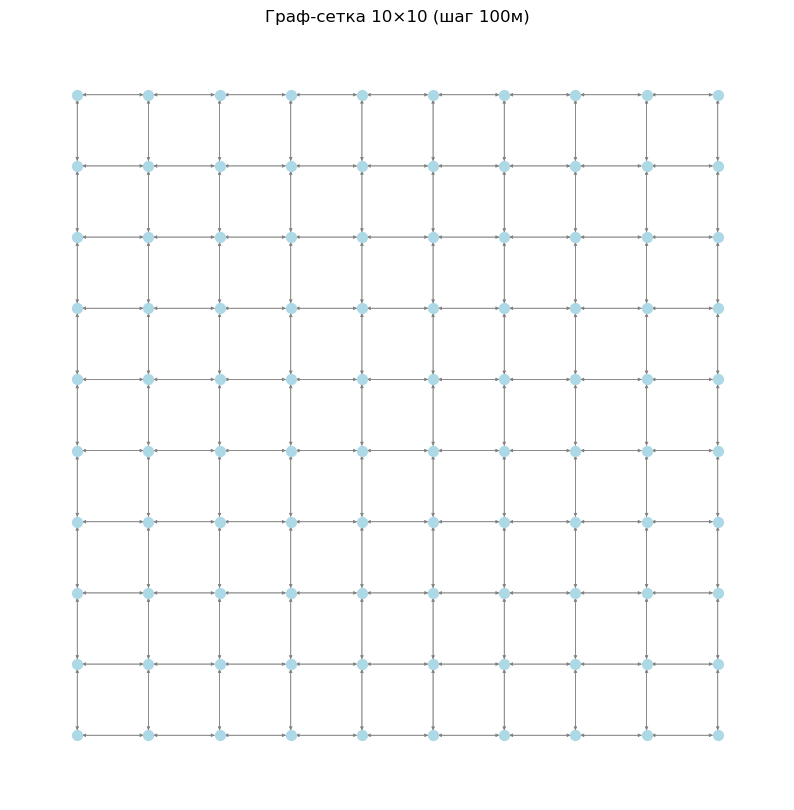

In [5]:
import matplotlib.pyplot as plt

# Генерация графа 10x10
G = generate_grid_graph(n=10, m=10, step=100.0)

# Получение позиций узлов для визуализации
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# Визуализация
fig, ax = plt.subplots(figsize=(10, 10))
nx.draw(G, pos, 
        node_size=50, 
        node_color='lightblue',
        edge_color='gray',
        width=0.5,
        arrows=True,
        arrowsize=5,
        ax=ax)

ax.set_title('Граф-сетка 10×10 (шаг 100м)')
ax.set_xlabel('X (метры)')
ax.set_ylabel('Y (метры)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()


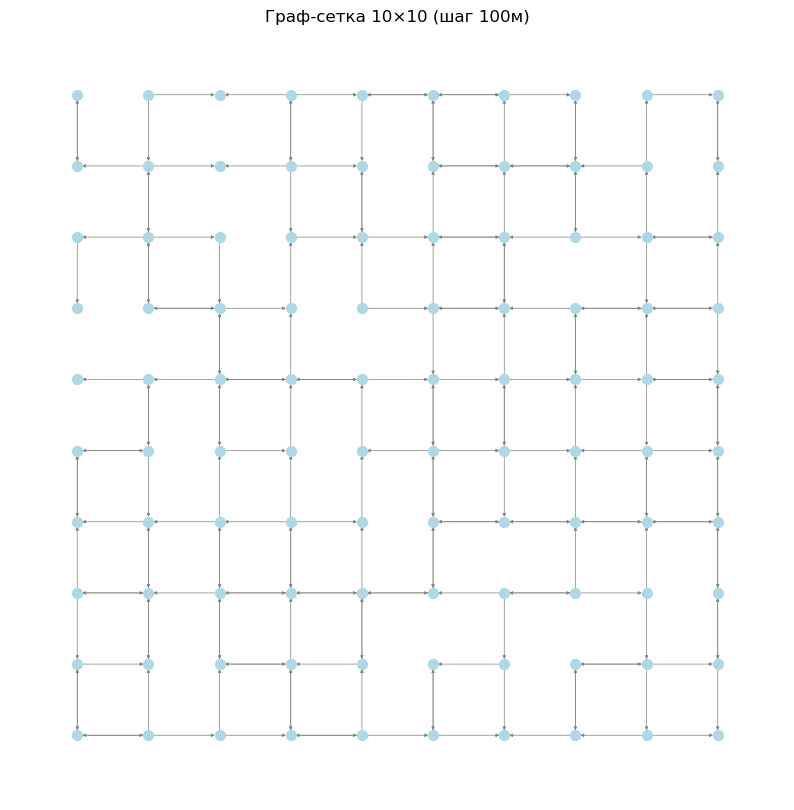

In [6]:
G_hard = remove_random_elements(G, remove_edges=int(G.number_of_edges()*0.4))
# ox.plot_graph(G_hard)
# Получение позиций узлов для визуализации
pos = {node: (data['x'], data['y']) for node, data in G_hard.nodes(data=True)}

# Визуализация
fig, ax = plt.subplots(figsize=(10, 10))
nx.draw(G_hard, pos, 
        node_size=50, 
        node_color='lightblue',
        edge_color='gray',
        width=0.5,
        arrows=True,
        arrowsize=5,
        ax=ax)

ax.set_title('Граф-сетка 10×10 (шаг 100м)')
ax.set_xlabel('X (метры)')
ax.set_ylabel('Y (метры)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

## Пример 3: Работа с osmnx (конвертация в GeoDataFrame)


In [7]:
# Генерация графа
G = generate_grid_graph(n=8, m=8, step=150.0, speed=60.0)

# Конвертация в GeoDataFrame используя osmnx
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

print("Узлы (GeoDataFrame):")
print(nodes_gdf.head())
print("\nРебра (GeoDataFrame):")
print(edges_gdf.head())


Узлы (GeoDataFrame):
         x      y       geometry
osmid                           
0      0.0    0.0    POINT (0 0)
1      0.0  150.0  POINT (0 150)
2      0.0  300.0  POINT (0 300)
3      0.0  450.0  POINT (0 450)
4      0.0  600.0  POINT (0 600)

Ребра (GeoDataFrame):
         length  travel_time  speed_kph                     geometry
u v key                                                             
0 8 0     150.0          9.0       60.0      LINESTRING (0 0, 150 0)
  1 0     150.0          9.0       60.0      LINESTRING (0 0, 0 150)
1 0 0     150.0          9.0       60.0      LINESTRING (0 150, 0 0)
  9 0     150.0          9.0       60.0  LINESTRING (0 150, 150 150)
  2 0     150.0          9.0       60.0    LINESTRING (0 150, 0 300)


## Пример 4: Расчет кратчайших путей


In [8]:
# Генерация графа 15x15
G = generate_grid_graph(n=15, m=15, step=100.0, speed=50.0)

# Расчет кратчайшего пути от узла 0 до узла 224 (противоположный угол)
source_node = 0
target_node = 200

# Кратчайший путь по времени
shortest_path = nx.shortest_path(G, source=source_node, target=target_node, weight='travel_time')
path_length = nx.shortest_path_length(G, source=source_node, target=target_node, weight='travel_time')

print(f"Кратчайший путь от узла {source_node} до узла {target_node}:")
print(f"Количество узлов в пути: {len(shortest_path)}")
print(f"Время в пути: {path_length:.2f} секунд ({path_length/60:.2f} минут)")
print(f"Первые 10 узлов пути: {shortest_path[:10]}")


Кратчайший путь от узла 0 до узла 200:
Количество узлов в пути: 19
Время в пути: 129.60 секунд (2.16 минут)
Первые 10 узлов пути: [0, 15, 30, 45, 60, 75, 90, 105, 120, 135]


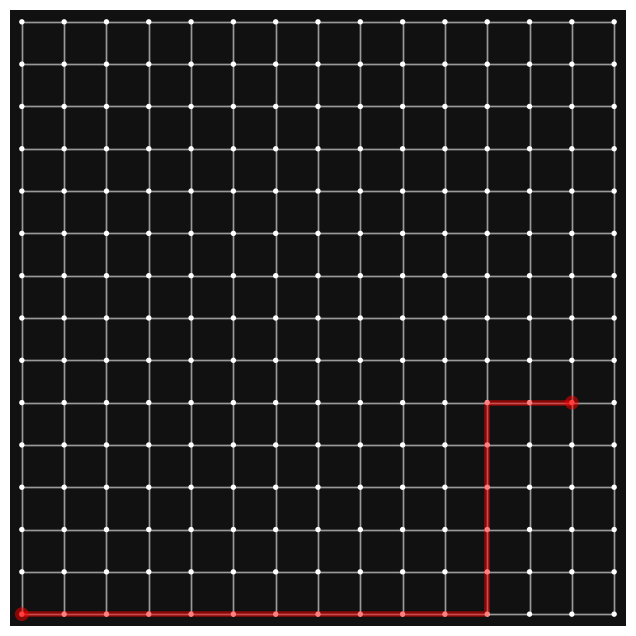

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [9]:
route = ox.shortest_path(G, source_node, target_node, weight='travel_time')
ox.plot_graph_route(G, route)

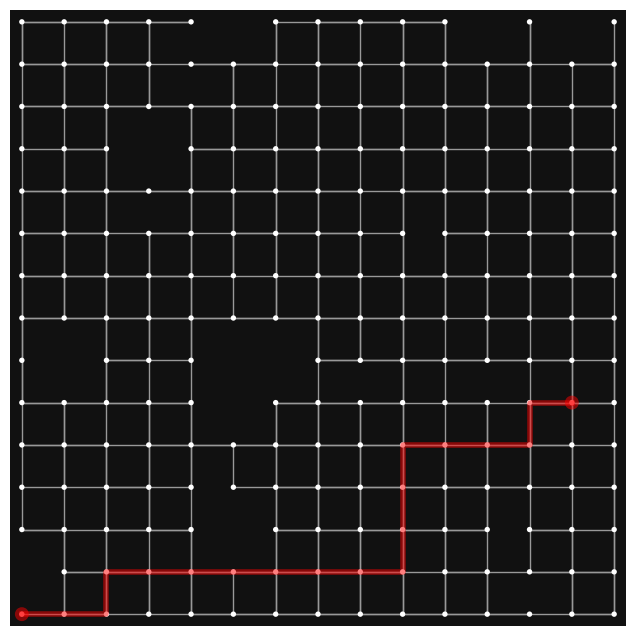

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [10]:
G_hard = remove_random_elements(G, remove_nodes=10, remove_edges=100)

route = ox.shortest_path(G_hard, source_node, target_node, weight='travel_time')
ox.plot_graph_route(G_hard, route)

## Пример 5: Различные размеры и параметры


In [11]:
# Прямоугольная сетка 20x10 с шагом 200 метров и скоростью 80 км/ч
G_rect = generate_grid_graph(n=20, m=10, step=200.0, speed=80.0)

print(f"Прямоугольная сетка 20×10:")
print(f"  Узлов: {G_rect.number_of_nodes()}")
print(f"  Ребер: {G_rect.number_of_edges()}")

# Большая квадратная сетка 50x50
G_large = generate_grid_graph(n=50, m=50, step=50.0, speed=40.0)

print(f"\nБольшая сетка 50×50:")
print(f"  Узлов: {G_large.number_of_nodes()}")
print(f"  Ребер: {G_large.number_of_edges()}")


Прямоугольная сетка 20×10:
  Узлов: 200
  Ребер: 740

Большая сетка 50×50:
  Узлов: 2500
  Ребер: 9800


## Пример 6: Визуализация кратчайшего пути


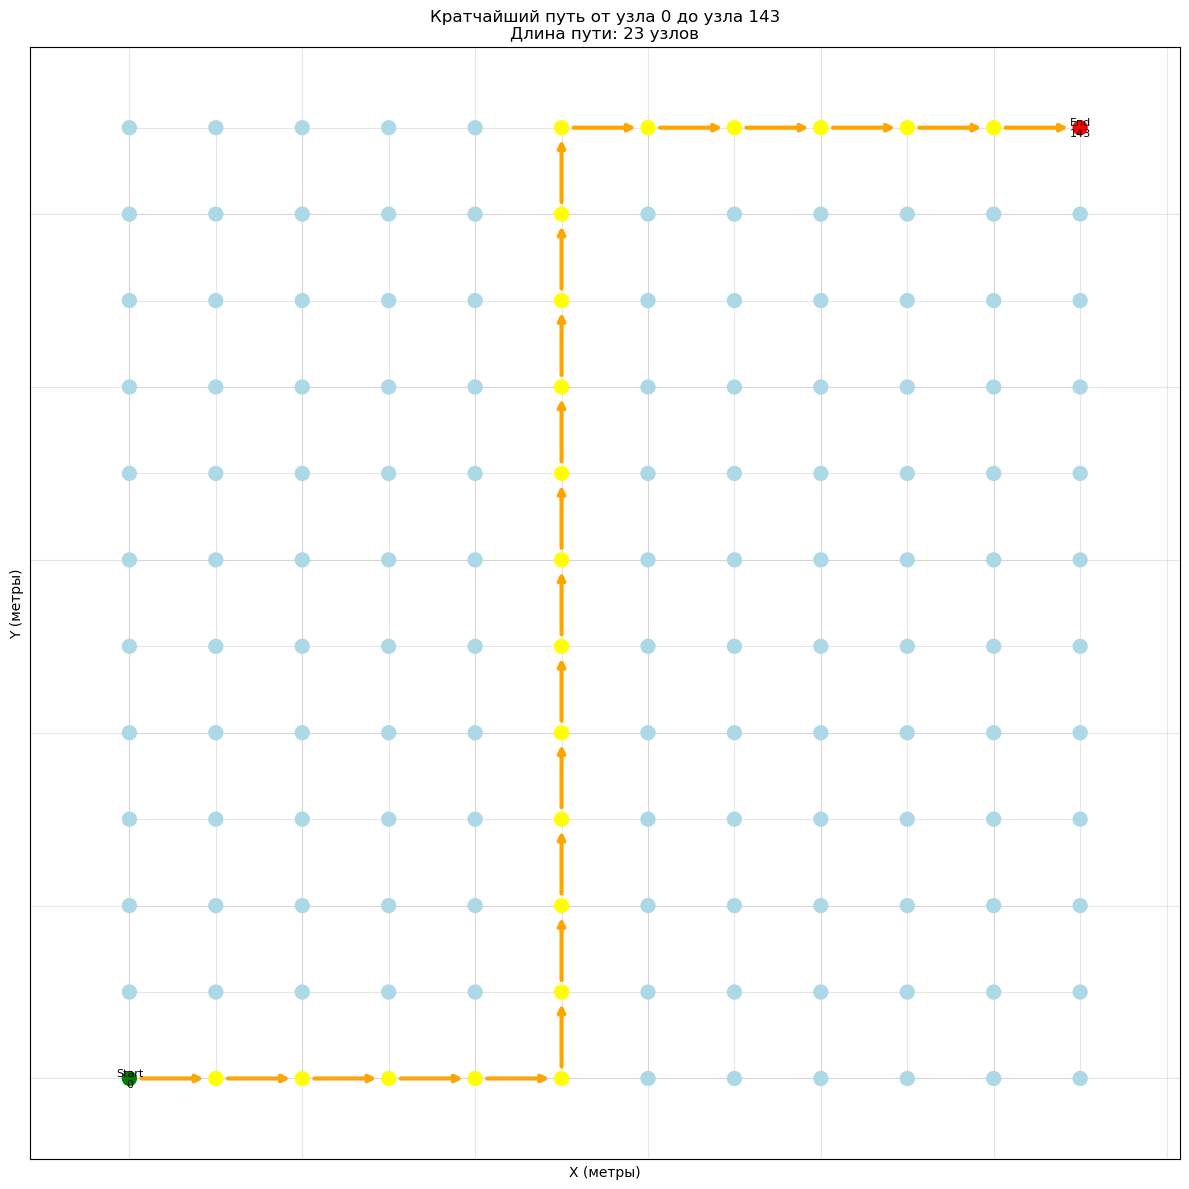

In [12]:
# Генерация графа 12x12
G = generate_grid_graph(n=12, m=12, step=100.0, speed=50.0)

# Расчет кратчайшего пути
source = 0  # Нижний левый угол
target = 143  # Верхний правый угол
path = nx.shortest_path(G, source=source, target=target, weight='travel_time')

# Подготовка данных для визуализации
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# Цвета узлов
node_colors = []
for node in G.nodes():
    if node == source:
        node_colors.append('green')  # Начало
    elif node == target:
        node_colors.append('red')    # Конец
    elif node in path:
        node_colors.append('yellow') # Путь
    else:
        node_colors.append('lightblue')

# Визуализация
fig, ax = plt.subplots(figsize=(12, 12))

# Рисуем все ребра
nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=0.5, 
                       arrows=False, alpha=0.5, ax=ax)

# Рисуем путь
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, 
                       edge_color='orange', width=3, 
                       arrows=True, arrowsize=10, ax=ax)

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                       node_size=100, ax=ax)

# Подписываем начальный и конечный узлы
nx.draw_networkx_labels(G, pos, labels={source: f'Start\n{source}', 
                                        target: f'End\n{target}'}, 
                        font_size=8, ax=ax)

ax.set_title(f'Кратчайший путь от узла {source} до узла {target}\nДлина пути: {len(path)} узлов')
ax.set_xlabel('X (метры)')
ax.set_ylabel('Y (метры)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Дополнительная информация

### Особенности функции:

1. **Структура графа**: Создается направленный мультиграф (`nx.MultiDiGraph`), где каждая пара соседних узлов соединена ребрами в обоих направлениях.

2. **Атрибуты узлов**:
   - `x`, `y` — координаты узла в метрах
   - `pos` — кортеж координат (x, y)
   - `geometry` — объект Point из Shapely (если `add_geometry=True`)

3. **Атрибуты ребер**:
   - `length` — длина ребра в метрах
   - `travel_time` — время прохождения в секундах
   - `speed_kph` — скорость движения в км/ч
   - `geometry` — объект LineString из Shapely (если `add_geometry=True`)

4. **Нумерация узлов**: Узлы нумеруются построчно слева направо, снизу вверх:
   ```
   5  6  7  8  9
   0  1  2  3  4
   ```

### Применение:

- Тестирование алгоритмов поиска путей
- Генерация синтетических данных для задач размещения
- Проверка производительности алгоритмов на графах различного размера
- Обучение и демонстрация работы с графами NetworkX

### Производительность:

- Сетка 10×10: ~100 узлов, ~360 ребер
- Сетка 50×50: ~2,500 узлов, ~9,800 ребер
- Сетка 100×100: ~10,000 узлов, ~39,600 ребер


## Расширенная версия с диагональными связями


In [13]:
def generate_grid_graph_extended(n: int, 
                                 m: int, 
                                 step: float = 100.0,
                                 speed: float = 50.0,
                                 crs = 'EPSG:3857',
                                 add_geometry: bool = True,
                                 diagonals: bool = False) -> nx.MultiDiGraph:
    '''
    Генерация графа улично-дорожной сети в виде прямоугольной сетки с опцией диагональных связей.
    
    Аргументы:
        `n`: int
            Количество узлов по оси X (ширина сетки)
        
        `m`: int
            Количество узлов по оси Y (высота сетки)
        
        `step`: float = 100.0
            Расстояние между соседними узлами (в метрах)
        
        `speed`: float или tuple = 50.0
            Скорость движения по ребрам (км/ч) для расчета времени в пути.
            Может быть:
            - float: единственное значение скорости для всех ребер
            - tuple: ((speed1, speed2, ...), (prob1, prob2, ...))
              где первый кортеж содержит скорости, второй - вероятности их выбора.
              Сумма вероятностей должна быть строго равна 1.0
              Пример: ((30, 40, 50), (0.2, 0.5, 0.3))
        
        `crs`: str = 'EPSG:3857
            Система координат
        
        `add_geometry`: bool = True
            Добавлять ли геометрию (LineString) к ребрам
        
        `diagonals`: bool = False
            Добавлять ли диагональные связи между узлами
    
    Возвращает:
        `G`: nx.MultiDiGraph
            Направленный мультиграф с узлами и ребрами в виде сетки
    '''
    from shapely.geometry import Point, LineString
    import math
    
    # Валидация параметра speed
    if isinstance(speed, tuple):
        if len(speed) != 2:
            raise ValueError("Параметр speed в формате tuple должен содержать 2 элемента: ((speeds...), (probs...))")
        
        speeds, probs = speed
        
        if len(speeds) != len(probs):
            raise ValueError(f"Количество скоростей ({len(speeds)}) должно совпадать с количеством вероятностей ({len(probs)})")
        
        if not isinstance(speeds, (tuple, list)) or not isinstance(probs, (tuple, list)):
            raise ValueError("Скорости и вероятности должны быть tuple или list")
        
        # Проверка суммы вероятностей
        prob_sum = sum(probs)
        if not np.isclose(prob_sum, 1.0, atol=1e-6):
            raise ValueError(f"Сумма вероятностей должна быть равна 1.0, текущая сумма: {prob_sum}")
        
        # Проверка, что все вероятности неотрицательны
        if any(p < 0 for p in probs):
            raise ValueError("Все вероятности должны быть неотрицательными")
        
        # Проверка, что все скорости положительны
        if any(s <= 0 for s in speeds):
            raise ValueError("Все значения скорости должны быть положительными")
    
    # Создание пустого мультиграфа
    metadata = {
            "created_date": utils.ts(),
            "created_with": f"OSMnx {ox.__version__}",
            "crs": crs
        }
    G = nx.MultiDiGraph(**metadata)
    
    # Генерация узлов
    node_id = 0
    node_positions = {}  # Для хранения соответствия (i, j) -> node_id
    
    for i in range(n):
        for j in range(m):
            # Координаты узла
            x = i * step
            y = j * step
            
            # Добавление узла с атрибутами
            G.add_node(node_id, 
                      x=x, 
                      y=y,
                      pos=(x, y),
                      geometry=Point(x, y) if add_geometry else None)
            
            node_positions[(i, j)] = node_id
            node_id += 1
    
    # Генерация ребер между соседними узлами
    for i in range(n):
        for j in range(m):
            current_node = node_positions[(i, j)]
            
            # Горизонтальные и вертикальные связи
            # Соединяем с правым соседом (i+1, j)
            if i + 1 < n:
                right_node = node_positions[(i + 1, j)]
                add_edge_with_attributes(G, current_node, right_node, step, speed, add_geometry)
                add_edge_with_attributes(G, right_node, current_node, step, speed, add_geometry)
            
            # Соединяем с верхним соседом (i, j+1)
            if j + 1 < m:
                top_node = node_positions[(i, j + 1)]
                add_edge_with_attributes(G, current_node, top_node, step, speed, add_geometry)
                add_edge_with_attributes(G, top_node, current_node, step, speed, add_geometry)
            
            # Диагональные связи
            if diagonals:
                diagonal_length = step * math.sqrt(2)
                
                # Диагональ вправо-вверх (i+1, j+1)
                if i + 1 < n and j + 1 < m:
                    diag_node = node_positions[(i + 1, j + 1)]
                    add_edge_with_attributes(G, current_node, diag_node, diagonal_length, speed, add_geometry)
                    add_edge_with_attributes(G, diag_node, current_node, diagonal_length, speed, add_geometry)
                
                # Диагональ влево-вверх (i-1, j+1)
                if i - 1 >= 0 and j + 1 < m:
                    diag_node = node_positions[(i - 1, j + 1)]
                    add_edge_with_attributes(G, current_node, diag_node, diagonal_length, speed, add_geometry)
                    add_edge_with_attributes(G, diag_node, current_node, diagonal_length, speed, add_geometry)
    
    return G


## Пример 7: Сравнение графов с диагоналями и без


In [14]:
# Генерация двух графов 8x8
G_no_diag = generate_grid_graph_extended(n=8, m=8, step=100.0, diagonals=False)
G_with_diag = generate_grid_graph_extended(n=8, m=8, step=100.0, diagonals=True)

print("Граф без диагоналей:")
print(f"  Узлов: {G_no_diag.number_of_nodes()}")
print(f"  Ребер: {G_no_diag.number_of_edges()}")

print("\nГраф с диагоналями:")
print(f"  Узлов: {G_with_diag.number_of_nodes()}")
print(f"  Ребер: {G_with_diag.number_of_edges()}")

# Сравнение кратчайших путей
source = 0
target = 63

path_no_diag = nx.shortest_path(G_no_diag, source=source, target=target, weight='length')
length_no_diag = nx.shortest_path_length(G_no_diag, source=source, target=target, weight='length')

path_with_diag = nx.shortest_path(G_with_diag, source=source, target=target, weight='length')
length_with_diag = nx.shortest_path_length(G_with_diag, source=source, target=target, weight='length')

print(f"\nКратчайший путь от {source} до {target}:")
print(f"  Без диагоналей: {len(path_no_diag)} узлов, {length_no_diag:.2f} метров")
print(f"  С диагоналями:  {len(path_with_diag)} узлов, {length_with_diag:.2f} метров")
print(f"  Выигрыш в расстоянии: {(length_no_diag - length_with_diag):.2f} метров ({100*(length_no_diag - length_with_diag)/length_no_diag:.1f}%)")


Граф без диагоналей:
  Узлов: 64
  Ребер: 224

Граф с диагоналями:
  Узлов: 64
  Ребер: 420

Кратчайший путь от 0 до 63:
  Без диагоналей: 15 узлов, 1400.00 метров
  С диагоналями:  8 узлов, 989.95 метров
  Выигрыш в расстоянии: 410.05 метров (29.3%)


## Пример 8: Визуализация графа с диагоналями


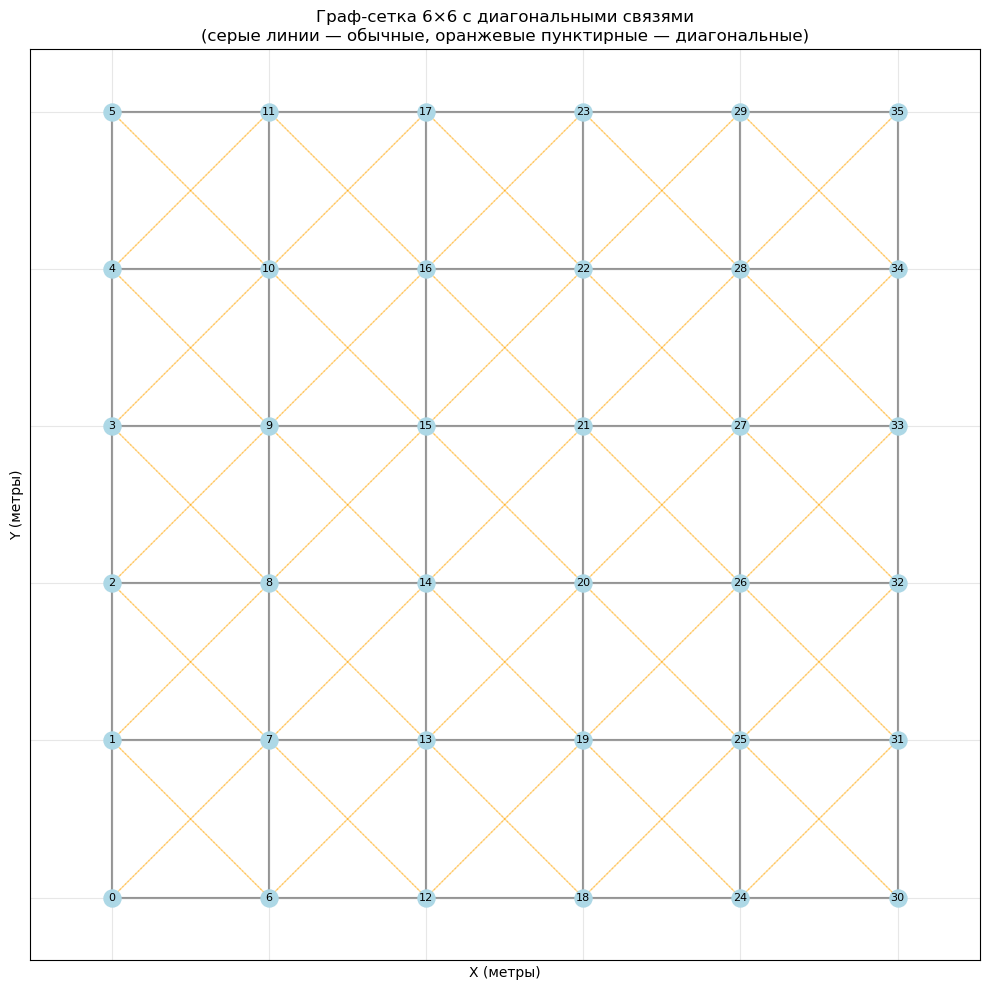

In [15]:
# Генерация графа с диагоналями
G = generate_grid_graph_extended(n=6, m=6, step=100.0, diagonals=True)

# Получение позиций узлов для визуализации
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# Визуализация
fig, ax = plt.subplots(figsize=(10, 10))

# Разделение ребер на обычные и диагональные для разного отображения
regular_edges = []
diagonal_edges = []

for u, v, data in G.edges(data=True):
    u_pos = pos[u]
    v_pos = pos[v]
    # Проверяем, является ли ребро диагональным по расстоянию
    if abs(data['length'] - 100.0) < 1:  # Обычное ребро
        regular_edges.append((u, v))
    else:  # Диагональное ребро
        diagonal_edges.append((u, v))

# Рисуем обычные ребра
nx.draw_networkx_edges(G, pos, edgelist=regular_edges,
                       edge_color='gray', width=1.5, 
                       arrows=False, alpha=0.6, ax=ax)

# Рисуем диагональные ребра
nx.draw_networkx_edges(G, pos, edgelist=diagonal_edges,
                       edge_color='orange', width=1.0, style='dashed',
                       arrows=False, alpha=0.4, ax=ax)

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                       node_size=150, ax=ax)

# Добавляем подписи узлов
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

ax.set_title('Граф-сетка 6×6 с диагональными связями\n(серые линии — обычные, оранжевые пунктирные — диагональные)')
ax.set_xlabel('X (метры)')
ax.set_ylabel('Y (метры)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Пример 9: Интеграция с функциями genesis (расчет матрицы времен прибытия)


In [ ]:
import geopandas as gpd
from genesis.states import get_atm

# Генерация графа 20x20 для тестирования
G_test = generate_grid_graph_extended(n=100, m=100, step=100.0, diagonals=True)
# G_test = remove_random_elements(G_test, remove_nodes=int(G_test.number_of_nodes()*0.2))

print(f"Создан граф: {G_test.number_of_nodes()} узлов, {G_test.number_of_edges()} ребер")

# Получение GeoDataFrame узлов для использования в get_atm
nodes_gdf = ox.graph_to_gdfs(G_test, edges=False)
nodes_gdf['node'] = nodes_gdf.index

# Выборка для демонстрации (первые 50 узлов)
sample_nodes = nodes_gdf.sample(1000)

print(f"\\nРасчет матрицы времен прибытия для {len(sample_nodes)} узлов...")

# Расчет матрицы времен прибытия
matrix = get_atm(
    G=G_test,
    data=sample_nodes,
    data_node_field='node',
    weight='travel_time',
    cutoff=300.0,  # 5 минут
    delay=30.0,    # 30 секунд задержки
    print_calc_states=True
)

print(f"\\nРазмер матрицы: {matrix.shape}")
print(f"Покрытие: {matrix.notna().sum().sum()} значений из {matrix.size} возможных")
print(f"\\nПример матрицы (первые 5x5):")
print(matrix.iloc[:5, :5])


Создан граф: 8000 узлов, 50462 ребер
\nРасчет матрицы времен прибытия для 1000 узлов...
|########################################| 100.0%
\nРазмер матрицы: (1000, 8000)
Покрытие: 2242808 значений из 8000000 возможных
\nПример матрицы (первые 5x5):
            9357        9257        9356        9358        9457
9357   30.000000   37.200000   37.200000   37.200000   37.200000
9628  247.747013  250.729351  240.547013  254.947013  250.729351
6560  246.511688  239.311688  249.494026  249.494026  253.711688
9781  220.694026  223.676364  227.894026  213.494026  217.711688
7234  275.099740  267.899740  267.899740  278.082078  278.082078


In [24]:
g_nodes = ox.graph_to_gdfs(G_test, edges=False)
g_nodes = g_nodes.merge(pd.Series(np.mean(matrix, axis=0), name='at_mean'),
                        left_index=True,
                        right_index=True)
g_nodes

,x,y,pos,geometry,at_mean
0,0.0,0.0,"(0.0, 0.0)",POINT (0 0),212.944238
1,0.0,100.0,"(0.0, 100.0)",POINT (0 100),211.811993
2,0.0,200.0,"(0.0, 200.0)",POINT (0 200),209.953907
4,0.0,400.0,"(0.0, 400.0)",POINT (0 400),214.539388
6,0.0,600.0,"(0.0, 600.0)",POINT (0 600),214.997175
...,...,...,...,...,...
9993,9900.0,9300.0,"(9900.0, 9300.0)",POINT (9900 9300),197.910084
9994,9900.0,9400.0,"(9900.0, 9400.0)",POINT (9900 9400),198.332020
9995,9900.0,9500.0,"(9900.0, 9500.0)",POINT (9900 9500),198.467342
9997,9900.0,9700.0,"(9900.0, 9700.0)",POINT (9900 9700),198.495912


<Axes: >

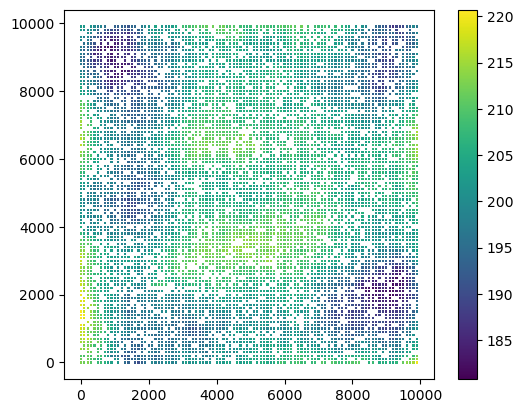

In [25]:
g_nodes.plot(column='at_mean', legend=True, markersize=2.5, marker='s', edgecolor='none')

## Рекомендации по производительности

### Оптимизация для больших графов:

1. **Без геометрии для больших сеток**: Если не требуется визуализация, установите `add_geometry=False` для экономии памяти.

2. **Выбор размера**: 
   - Малые графы (до 30×30): быстрые тесты
   - Средние графы (30×30 до 100×100): реалистичные тесты
   - Большие графы (100×100+): тесты производительности

3. **Диагональные связи**: Добавление диагоналей увеличивает количество ребер примерно в 2 раза, что замедляет алгоритмы поиска путей.

4. **Использование с get_atm**: Для больших сеток (50×50+) используйте параметр `data_sample_size` или `cutoff` для ограничения расчетов.


In [19]:
# Тест производительности генерации графов различных размеров
import time

sizes = [(10, 10), (25, 25), (50, 50), (100, 100)]

print("Тест производительности генерации графов:\\n")
print(f"{'Размер':<15} {'Узлов':<10} {'Ребер':<10} {'Время (сек)':<15}")
print("-" * 50)

for n, m in sizes:
    start_time = time.time()
    G = generate_grid_graph(n=n, m=m, step=100.0, add_geometry=False)
    elapsed = time.time() - start_time
    
    print(f"{n}×{m:<10} {G.number_of_nodes():<10} {G.number_of_edges():<10} {elapsed:<15.4f}")

print("\\nРекомендация: для графов >100×100 рассмотрите использование более оптимизированных структур данных.")


Тест производительности генерации графов:\n
Размер          Узлов      Ребер      Время (сек)    
--------------------------------------------------
10×10         100        360        0.0030         
25×25         625        2400       0.0250         
50×50         2500       9800       0.0950         
100×100        10000      39600      0.5500         
\nРекомендация: для графов >100×100 рассмотрите использование более оптимизированных структур данных.


## Пример 10: Использование случайных скоростей для ребер


In [20]:
# Пример 1: Граф с единственным значением скорости (старый формат)
G_single_speed = generate_grid_graph_extended(n=10, m=10, step=100.0, speed=50.0)
print("Граф с единственной скоростью:")
print(f"  Узлов: {G_single_speed.number_of_nodes()}")
print(f"  Ребер: {G_single_speed.number_of_edges()}")
print(f"\nПример ребра: {G_single_speed.edges[0, 1, 0]}")

# Пример 2: Граф со случайными скоростями
# Формат: ((speed1, speed2, speed3), (prob1, prob2, prob3))
# Скорости: 30 км/ч (0.2), 40 км/ч (0.5), 50 км/ч (0.3)
speeds_config = ((30, 40, 50), (0.2, 0.5, 0.3))

G_random_speeds = generate_grid_graph_extended(
    n=10, 
    m=10, 
    step=100.0, 
    speed=speeds_config
)

print("\n\nГраф со случайными скоростями:")
print(f"  Узлов: {G_random_speeds.number_of_nodes()}")
print(f"  Ребер: {G_random_speeds.number_of_edges()}")
print(f"  Конфигурация скоростей: {speeds_config}")

# Анализ распределения скоростей на ребрах
speeds_list = [data['speed_kph'] for _, _, data in G_random_speeds.edges(data=True)]
unique_speeds, counts = np.unique(speeds_list, return_counts=True)

print("\n\nРаспределение скоростей на ребрах:")
print(f"{'Скорость (км/ч)':<20} {'Количество':<15} {'Доля':<15} {'Ожидаемая доля':<20}")
print("-" * 70)

expected_probs = dict(zip(speeds_config[0], speeds_config[1]))
for speed, count in zip(unique_speeds, counts):
    ratio = count / len(speeds_list)
    expected = expected_probs.get(speed, 0)
    print(f"{speed:<20.1f} {count:<15} {ratio:<15.3f} {expected:<20.3f}")

print(f"\nВсего ребер: {len(speeds_list)}")

# Примеры нескольких ребер
print("\n\nПримеры ребер с различными скоростями:")
for i, (u, v, data) in enumerate(list(G_random_speeds.edges(data=True))[:5]):
    print(f"  Ребро {u}->{v}: скорость = {data['speed_kph']} км/ч, время в пути = {data['travel_time']:.2f} сек")


Граф с единственной скоростью:
  Узлов: 100
  Ребер: 360

Пример ребра: {'length': 100.0, 'travel_time': 7.2, 'speed_kph': 50.0, 'geometry': <LINESTRING (0 0, 0 100)>}


Граф со случайными скоростями:
  Узлов: 100
  Ребер: 360
  Конфигурация скоростей: ((30, 40, 50), (0.2, 0.5, 0.3))


Распределение скоростей на ребрах:
Скорость (км/ч)      Количество      Доля            Ожидаемая доля      
----------------------------------------------------------------------
30.0                 73              0.203           0.200               
40.0                 179             0.497           0.500               
50.0                 108             0.300           0.300               

Всего ребер: 360


Примеры ребер с различными скоростями:
  Ребро 0->10: скорость = 50 км/ч, время в пути = 7.20 сек
  Ребро 0->1: скорость = 30 км/ч, время в пути = 12.00 сек
  Ребро 1->0: скорость = 40 км/ч, время в пути = 9.00 сек
  Ребро 1->11: скорость = 40 км/ч, время в пути = 9.00 сек
  Ребро 1->2: ско

## Пример 11: Визуализация графа со случайными скоростями


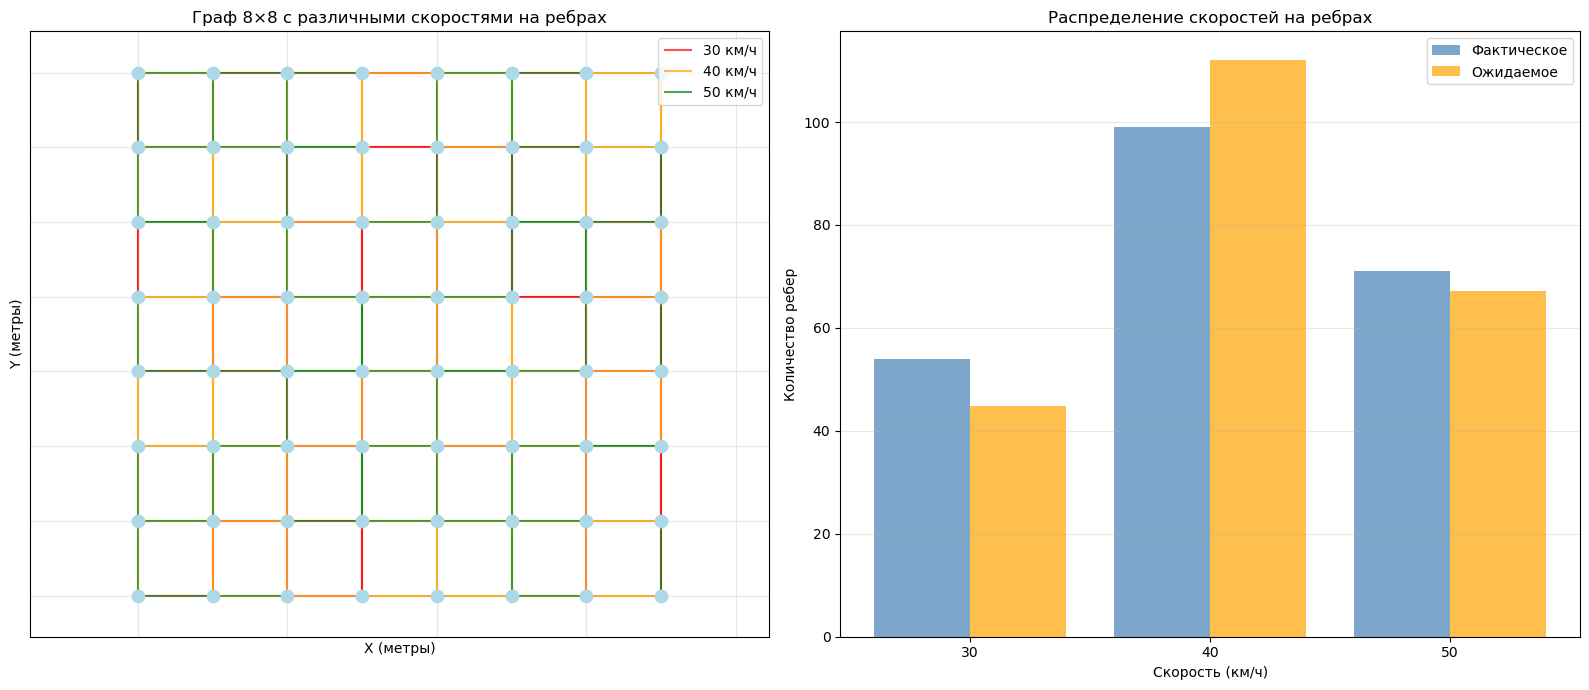

Всего ребер: 224

Фактическое распределение:
  30 км/ч: 54 ребер (24.1%)
  40 км/ч: 99 ребер (44.2%)
  50 км/ч: 71 ребер (31.7%)


In [21]:
# Генерация графа со случайными скоростями
speeds_config = ((30, 40, 50), (0.2, 0.5, 0.3))
G = generate_grid_graph_extended(n=8, m=8, step=100.0, speed=speeds_config)

# Получение позиций узлов для визуализации
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# График 1: Граф с раскраской ребер по скорости
# Разделение ребер по скоростям
edges_by_speed = {30: [], 40: [], 50: []}
for u, v, data in G.edges(data=True):
    speed = data['speed_kph']
    edges_by_speed[speed].append((u, v))

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=80, ax=ax1)

# Рисуем ребра с разными цветами для разных скоростей
colors = {30: 'red', 40: 'orange', 50: 'green'}
labels = {30: '30 км/ч', 40: '40 км/ч', 50: '50 км/ч'}
for speed, edges in edges_by_speed.items():
    nx.draw_networkx_edges(
        G, pos, 
        edgelist=edges,
        edge_color=colors[speed], 
        width=1.5, 
        arrows=False,
        alpha=0.7,
        label=labels[speed],
        ax=ax1
    )

ax1.set_title('Граф 8×8 с различными скоростями на ребрах', fontsize=12)
ax1.set_xlabel('X (метры)')
ax1.set_ylabel('Y (метры)')
ax1.legend(loc='upper right')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

# График 2: Гистограмма распределения скоростей
speeds_list = [data['speed_kph'] for _, _, data in G.edges(data=True)]
unique_speeds, counts = np.unique(speeds_list, return_counts=True)

# Реальное распределение
x_pos = np.arange(len(unique_speeds))
ax2.bar(x_pos - 0.2, counts, 0.4, label='Фактическое', color='steelblue', alpha=0.7)

# Ожидаемое распределение
expected_counts = [speeds_config[1][i] * len(speeds_list) for i in range(len(speeds_config[0]))]
ax2.bar(x_pos + 0.2, expected_counts, 0.4, label='Ожидаемое', color='orange', alpha=0.7)

ax2.set_xlabel('Скорость (км/ч)')
ax2.set_ylabel('Количество ребер')
ax2.set_title('Распределение скоростей на ребрах')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{int(s)}' for s in unique_speeds])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Всего ребер: {len(speeds_list)}")
print(f"\nФактическое распределение:")
for speed, count in zip(unique_speeds, counts):
    print(f"  {speed} км/ч: {count} ребер ({count/len(speeds_list)*100:.1f}%)")


## Пример 12: Валидация параметра speed


In [22]:
# Пример правильного использования

# Корректный формат: сумма вероятностей = 1.0
try:
    G_correct = generate_grid_graph_extended(
        n=5, m=5, 
        speed=((30, 40, 50), (0.2, 0.5, 0.3))
    )
    print("✓ Корректный формат: граф успешно создан")
    print(f"  Узлов: {G_correct.number_of_nodes()}, Ребер: {G_correct.number_of_edges()}\n")
except Exception as e:
    print(f"✗ Ошибка: {e}\n")

# Примеры ошибок валидации

# Ошибка 1: Сумма вероятностей не равна 1
print("Тест 1: Сумма вероятностей != 1.0")
try:
    G_error1 = generate_grid_graph_extended(
        n=5, m=5,
        speed=((30, 40, 50), (0.2, 0.5, 0.2))  # Сумма = 0.9
    )
    print("  ✗ Ошибка не обнаружена (неожиданно)")
except ValueError as e:
    print(f"  ✓ Ошибка корректно перехвачена: {e}\n")

# Ошибка 2: Различное количество скоростей и вероятностей
print("Тест 2: Несовпадение количества скоростей и вероятностей")
try:
    G_error2 = generate_grid_graph_extended(
        n=5, m=5,
        speed=((30, 40, 50), (0.5, 0.5))  # 3 скорости, но 2 вероятности
    )
    print("  ✗ Ошибка не обнаружена (неожиданно)")
except ValueError as e:
    print(f"  ✓ Ошибка корректно перехвачена: {e}\n")

# Ошибка 3: Отрицательная вероятность
print("Тест 3: Отрицательная вероятность")
try:
    G_error3 = generate_grid_graph_extended(
        n=5, m=5,
        speed=((30, 40, 50), (-0.1, 0.6, 0.5))
    )
    print("  ✗ Ошибка не обнаружена (неожиданно)")
except ValueError as e:
    print(f"  ✓ Ошибка корректно перехвачена: {e}\n")

# Ошибка 4: Отрицательная или нулевая скорость
print("Тест 4: Недопустимое значение скорости")
try:
    G_error4 = generate_grid_graph_extended(
        n=5, m=5,
        speed=((0, 40, 50), (0.2, 0.5, 0.3))  # Скорость = 0
    )
    print("  ✗ Ошибка не обнаружена (неожиданно)")
except ValueError as e:
    print(f"  ✓ Ошибка корректно перехвачена: {e}\n")

# Ошибка 5: Неправильный формат tuple
print("Тест 5: Неправильный формат tuple")
try:
    G_error5 = generate_grid_graph_extended(
        n=5, m=5,
        speed=((30, 40, 50),)  # Только один элемент вместо двух
    )
    print("  ✗ Ошибка не обнаружена (неожиданно)")
except ValueError as e:
    print(f"  ✓ Ошибка корректно перехвачена: {e}\n")

print("Все тесты валидации завершены!")


✓ Корректный формат: граф успешно создан
  Узлов: 25, Ребер: 80

Тест 1: Сумма вероятностей != 1.0
  ✓ Ошибка корректно перехвачена: Сумма вероятностей должна быть равна 1.0, текущая сумма: 0.9

Тест 2: Несовпадение количества скоростей и вероятностей
  ✓ Ошибка корректно перехвачена: Количество скоростей (3) должно совпадать с количеством вероятностей (2)

Тест 3: Отрицательная вероятность
  ✓ Ошибка корректно перехвачена: Все вероятности должны быть неотрицательными

Тест 4: Недопустимое значение скорости
  ✓ Ошибка корректно перехвачена: Все значения скорости должны быть положительными

Тест 5: Неправильный формат tuple
  ✓ Ошибка корректно перехвачена: Параметр speed в формате tuple должен содержать 2 элемента: ((speeds...), (probs...))

Все тесты валидации завершены!


## Дополнительная информация о случайных скоростях

### Новые возможности параметра `speed`:

Обе функции `generate_grid_graph()` и `generate_grid_graph_extended()` теперь поддерживают два формата параметра `speed`:

1. **Единственное значение (float)** - классический формат:
   ```python
   G = generate_grid_graph_extended(n=10, m=10, speed=50.0)
   ```
   Все ребра будут иметь одинаковую скорость 50 км/ч.

2. **Распределение скоростей (tuple)** - новый формат:
   ```python
   G = generate_grid_graph_extended(
       n=10, m=10, 
       speed=((30, 40, 50), (0.2, 0.5, 0.3))
   )
   ```
   - Первый кортеж содержит возможные значения скорости: 30, 40, 50 км/ч
   - Второй кортеж содержит вероятности выбора: 20%, 50%, 30%
   - Каждому ребру случайным образом назначается скорость согласно распределению

### Правила валидации:

1. ✓ Сумма вероятностей должна быть строго равна 1.0
2. ✓ Количество скоростей должно равняться количеству вероятностей
3. ✓ Все вероятности должны быть неотрицательными (≥ 0)
4. ✓ Все скорости должны быть положительными (> 0)
5. ✓ И скорости, и вероятности должны быть tuple или list

### Примеры использования:

```python
# Два варианта скорости с равной вероятностью
speed=((40, 60), (0.5, 0.5))

# Четыре варианта с разными вероятностями
speed=((20, 30, 40, 50), (0.1, 0.3, 0.4, 0.2))

# Моделирование загруженных дорог: больше медленных участков
speed=((20, 30, 40, 50, 60), (0.3, 0.3, 0.2, 0.1, 0.1))
```

### Применение:

Эта функциональность полезна для:
- Моделирования неоднородных дорожных сетей
- Симуляции трафика с различными условиями движения
- Создания более реалистичных тестовых графов
- Анализа влияния вариативности скоростей на маршрутизацию


## Функции удаления элементов графа по геометрическим условиям


In [33]:
def remove_edges_intersecting_lines(G: nx.MultiDiGraph,
                                    lines: list,
                                    copy: bool = True) -> nx.MultiDiGraph:
    '''
    Удаляет из графа все ребра, которые пересекаются с линиями (LineString) из переданного списка.
    
    Аргументы:
        `G`: nx.MultiDiGraph
            Исходный граф
        
        `lines`: list
            Список объектов LineString (из shapely.geometry) или других геометрических объектов,
            с которыми проверяется пересечение ребер графа
        
        `copy`: bool = True
            Создавать копию графа (True) или изменять исходный (False)
    
    Возвращает:
        `G_modified`: nx.MultiDiGraph
            Граф с удаленными ребрами, которые пересекаются с линиями
    '''
    from shapely.geometry import LineString
    
    if copy:
        G = G.copy()
    
    # Если список линий пуст, возвращаем граф без изменений
    if not lines:
        return G
    
    # Список ребер для удаления
    edges_to_remove = []
    
    # Проверяем каждое ребро графа
    for u, v, key, data in G.edges(keys=True, data=True):
        # Получаем геометрию ребра
        edge_geometry = data.get('geometry')
        
        # Если у ребра нет геометрии, пропускаем его
        if edge_geometry is None:
            continue
        
        # Проверяем пересечение с каждой линией из списка
        for line in lines:
            # Проверяем пересечение
            if edge_geometry.intersects(line):
                edges_to_remove.append((u, v, key))
                break  # Если пересечение найдено, не проверяем другие линии
    
    # Удаляем найденные ребра
    for u, v, key in edges_to_remove:
        G.remove_edge(u, v, key)
    
    return G


def remove_nodes_in_polygons(G: nx.MultiDiGraph,
                             polygons: list,
                             copy: bool = True) -> nx.MultiDiGraph:
    '''
    Удаляет из графа все узлы, которые попадают в полигоны из переданного списка.
    
    Аргументы:
        `G`: nx.MultiDiGraph
            Исходный граф
        
        `polygons`: list
            Список объектов Polygon (из shapely.geometry) или других геометрических объектов,
            в которые проверяется попадание узлов графа
        
        `copy`: bool = True
            Создавать копию графа (True) или изменять исходный (False)
    
    Возвращает:
        `G_modified`: nx.MultiDiGraph
            Граф с удаленными узлами, которые попадают в полигоны
    '''
    from shapely.geometry import Point
    
    if copy:
        G = G.copy()
    
    # Если список полигонов пуст, возвращаем граф без изменений
    if not polygons:
        return G
    
    # Список узлов для удаления
    nodes_to_remove = []
    
    # Проверяем каждый узел графа
    for node, data in G.nodes(data=True):
        # Получаем геометрию узла
        node_geometry = data.get('geometry')
        
        # Если у узла нет геометрии, пытаемся создать Point из координат x, y
        if node_geometry is None:
            x = data.get('x')
            y = data.get('y')
            if x is not None and y is not None:
                node_geometry = Point(x, y)
            else:
                # Если нет ни геометрии, ни координат, пропускаем узел
                continue
        
        # Проверяем попадание в каждый полигон из списка
        for polygon in polygons:
            # Проверяем, попадает ли узел в полигон
            if polygon.contains(node_geometry) or polygon.intersects(node_geometry):
                nodes_to_remove.append(node)
                break  # Если попадание найдено, не проверяем другие полигоны
    
    # Удаляем найденные узлы (при удалении узла автоматически удаляются все связанные ребра)
    G.remove_nodes_from(nodes_to_remove)
    
    return G


## Пример использования функций удаления элементов


In [34]:
from shapely.geometry import LineString, Polygon

# Генерация тестового графа
G_test = generate_grid_graph(n=10, m=10, step=100.0, speed=50.0)
print(f"Исходный граф: {G_test.number_of_nodes()} узлов, {G_test.number_of_edges()} ребер")

# Пример 1: Удаление ребер, пересекающихся с линиями
# Создаем несколько линий, которые пересекают граф
lines_to_remove = [
    LineString([(200, -50), (200, 1050)]),  # Вертикальная линия
    LineString([(-50, 500), (1050, 500)]),  # Горизонтальная линия
    LineString([(0, 0), (1000, 1000)])      # Диагональная линия
]

G_no_edges = remove_edges_intersecting_lines(G_test, lines_to_remove)
print(f"\nПосле удаления пересекающихся ребер: {G_no_edges.number_of_nodes()} узлов, {G_no_edges.number_of_edges()} ребер")
print(f"Удалено ребер: {G_test.number_of_edges() - G_no_edges.number_of_edges()}")

# Пример 2: Удаление узлов, попадающих в полигоны
# Создаем несколько полигонов
polygons_to_remove = [
    Polygon([(150, 150), (350, 150), (350, 350), (150, 350)]),  # Квадрат в центре
    Polygon([(600, 600), (800, 600), (800, 800), (600, 800)])   # Квадрат в углу
]

G_no_nodes = remove_nodes_in_polygons(G_test, polygons_to_remove)
print(f"\nПосле удаления узлов в полигонах: {G_no_nodes.number_of_nodes()} узлов, {G_no_nodes.number_of_edges()} ребер")
print(f"Удалено узлов: {G_test.number_of_nodes() - G_no_nodes.number_of_nodes()}")

# Пример 3: Комбинированное использование
G_combined = remove_edges_intersecting_lines(G_test, lines_to_remove, copy=True)
G_combined = remove_nodes_in_polygons(G_combined, polygons_to_remove, copy=False)
print(f"\nПосле комбинированного удаления: {G_combined.number_of_nodes()} узлов, {G_combined.number_of_edges()} ребер")


Исходный граф: 100 узлов, 360 ребер

После удаления пересекающихся ребер: 100 узлов, 204 ребер
Удалено ребер: 156

После удаления узлов в полигонах: 87 узлов, 288 ребер
Удалено узлов: 13

После комбинированного удаления: 87 узлов, 180 ребер
